<a href="https://colab.research.google.com/github/TearG/Alura---Telecom-X/blob/master/TelecomX_VanessaAlura_BR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracão

In [1]:
import pandas as pd

# Link "Raw" com os dados puros em JSON
url_raw = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/main/TelecomX_Data.json'

# Extraindo os dados da API simulada
df = pd.read_json(url_raw)

# Visualizando as 5 primeiras linhas para entender a nossa nave
display(df.head())

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformação

In [4]:
# ==========================================
# BLOCO 2: TRANSFORMAÇÃO (T)
# ==========================================

# 1. TRATANDO AS INCONSISTÊNCIAS
# Convertendo a coluna de gastos totais de texto (object) para decimal (float)
# Valores em branco (" ") serão forçados a virar nulos (NaN)
df_normalizado['account.Charges.Total'] = pd.to_numeric(df_normalizado['account.Charges.Total'], errors='coerce')

# Preenchendo os valores nulos gerados (clientes recém-chegados) com 0
df_normalizado['account.Charges.Total'].fillna(0, inplace=True)


# 2. PADRONIZAÇÃO E TRANSFORMAÇÃO DE DADOS (Limpeza e Tradução)
# Criando um dicionário para renomear as colunas (removendo prefixos e traduzindo)
colunas_traduzidas = {
    'customerID': 'id_cliente',
    'Churn': 'evasao',
    'customer.gender': 'genero',
    'customer.SeniorCitizen': 'idoso', # 0 = Não, 1 = Sim
    'customer.Partner': 'tem_parceiro',
    'customer.Dependents': 'tem_dependentes',
    'customer.tenure': 'meses_contrato',
    'phone.PhoneService': 'servico_telefone',
    'phone.MultipleLines': 'multiplas_linhas',
    'internet.InternetService': 'servico_internet',
    'internet.OnlineSecurity': 'seguranca_online',
    'internet.OnlineBackup': 'backup_online',
    'internet.DeviceProtection': 'protecao_dispositivo',
    'internet.TechSupport': 'suporte_tecnico',
    'internet.StreamingTV': 'streaming_tv',
    'internet.StreamingMovies': 'streaming_filmes',
    'account.Contract': 'tipo_contrato',
    'account.PaperlessBilling': 'fatura_digital',
    'account.PaymentMethod': 'metodo_pagamento',
    'account.Charges.Monthly': 'gasto_mensal',
    'account.Charges.Total': 'gasto_total'
}

# Aplicando a renomeação
df_normalizado.rename(columns=colunas_traduzidas, inplace=True)

# Criando um dicionário para traduzir os valores dentro das linhas
traducao_valores = {
    'Yes': 'Sim',
    'No': 'Nao',
    'Male': 'Masculino',
    'Female': 'Feminino',
    'No phone service': 'Sem servico de telefone',
    'No internet service': 'Sem servico de internet',
    'Month-to-month': 'Mensal',
    'One year': 'Anual',
    'Two year': 'Bienal',
    'Fiber optic': 'Fibra optica'
}

# Aplicando a substituição dos valores no DataFrame inteiro
df_normalizado = df_normalizado.replace(traducao_valores)

# Verificando como ficou a nossa base final pronta para a análise!
display(df_normalizado.head())

/tmp/ipykernel_234/1654201114.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_normalizado['account.Charges.Total'].fillna(0, inplace=True)


,id_cliente,evasao,genero,idoso,tem_parceiro,tem_dependentes,meses_contrato,servico_telefone,multiplas_linhas,servico_internet,...,backup_online,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,gasto_mensal,gasto_total
0,0002-ORFBO,Nao,Feminino,0,Sim,Sim,9,Sim,Nao,DSL,...,Sim,Nao,Sim,Sim,Nao,Anual,Sim,Mailed check,65.6,593.30
1,0003-MKNFE,Nao,Masculino,0,Nao,Nao,9,Sim,Sim,DSL,...,Nao,Nao,Nao,Nao,Sim,Mensal,Nao,Mailed check,59.9,542.40
2,0004-TLHLJ,Sim,Masculino,0,Nao,Nao,4,Sim,Nao,Fibra optica,...,Nao,Sim,Nao,Nao,Nao,Mensal,Sim,Electronic check,73.9,280.85
3,0011-IGKFF,Sim,Masculino,1,Sim,Nao,13,Sim,Nao,Fibra optica,...,Sim,Sim,Nao,Sim,Sim,Mensal,Sim,Electronic check,98.0,1237.85
4,0013-EXCHZ,Sim,Feminino,1,Sim,Nao,3,Sim,Nao,Fibra optica,...,Nao,Nao,Sim,Sim,Nao,Mensal,Sim,Mailed check,83.9,267.40


#📊 Carga e análise

In [6]:
# ==========================================
# BLOCO 3: CARGA E ANÁLISE
# ==========================================

# 1. ANÁLISE DESCRITIVA
# Gerando estatísticas descritivas para as variáveis numéricas
display(df_normalizado.describe())

# Gerando um resumo para as variáveis categóricas (texto)
display(df_normalizado.describe(include='object'))

,idoso,meses_contrato,gasto_mensal,gasto_total
count,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098,2277.182035
std,0.369074,24.571773,30.129572,2268.648587
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.425000,396.200000
50%,0.000000,29.000000,70.300000,1389.200000
75%,0.000000,55.000000,89.875000,3778.525000
max,1.000000,72.000000,118.750000,8684.800000


,id_cliente,evasao,genero,tem_parceiro,tem_dependentes,servico_telefone,multiplas_linhas,servico_internet,seguranca_online,backup_online,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento
count,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267
unique,7267,3,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
top,9995-HOTOH,Nao,Masculino,Nao,Nao,Sim,Nao,Fibra optica,Nao,Nao,Nao,Nao,Nao,Nao,Mensal,Sim,Electronic check
freq,1,5174,3675,3749,5086,6560,3495,3198,3608,3182,3195,3582,2896,2870,4005,4311,2445


Valores originais na coluna evasao:
evasao
Nao    5174
Sim    1869
        224
Name: count, dtype: int64
----------------------------------------


/tmp/ipykernel_234/2432570576.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.countplot(data=df_analise, x='evasao', palette=['#2ecc71', '#e74c3c']) # Verde para Nao, Vermelho para Sim


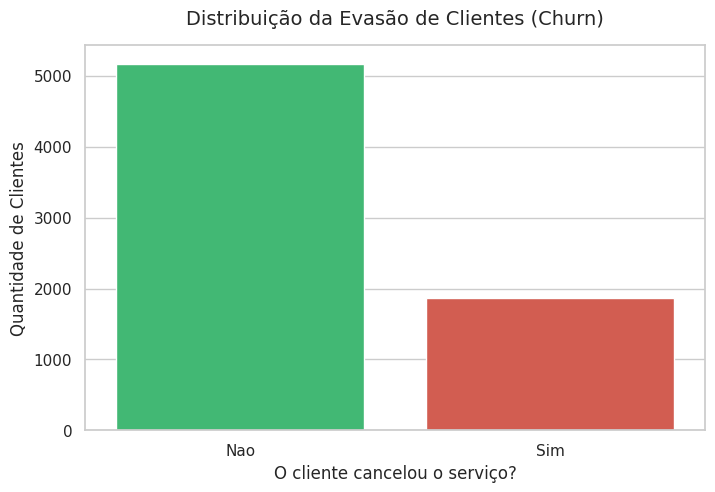


Taxa de Evasão (Porcentagem):
evasao
Nao    73.46
Sim    26.54
Name: proportion, dtype: float64


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# 2. DISTRIBUIÇÃO DA EVASÃO

# Descobrindo o mistério: quais são os 3 valores da coluna evasao?
print("Valores originais na coluna evasao:")
print(df_normalizado['evasao'].value_counts())
print("-" * 40)

# Filtrando o DataFrame para ignorar os dados sujos (mantendo apenas Sim e Nao)
# Geralmente, dados sem a marcação de Churn não servem para o nosso modelo
df_analise = df_normalizado[df_normalizado['evasao'].isin(['Sim', 'Nao'])]

# Configurando o estilo do gráfico
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

# Criando o gráfico de barras
grafico = sns.countplot(data=df_analise, x='evasao', palette=['#2ecc71', '#e74c3c']) # Verde para Nao, Vermelho para Sim

# Adicionando título e rótulos
plt.title('Distribuição da Evasão de Clientes (Churn)', fontsize=14, pad=15)
plt.xlabel('O cliente cancelou o serviço?', fontsize=12)
plt.ylabel('Quantidade de Clientes', fontsize=12)

# Exibindo o gráfico
plt.show()

# Calculando a porcentagem exata para colocar no relatório depois
taxa_evasao = df_analise['evasao'].value_counts(normalize=True) * 100
print(f"\nTaxa de Evasão (Porcentagem):\n{taxa_evasao.round(2)}")


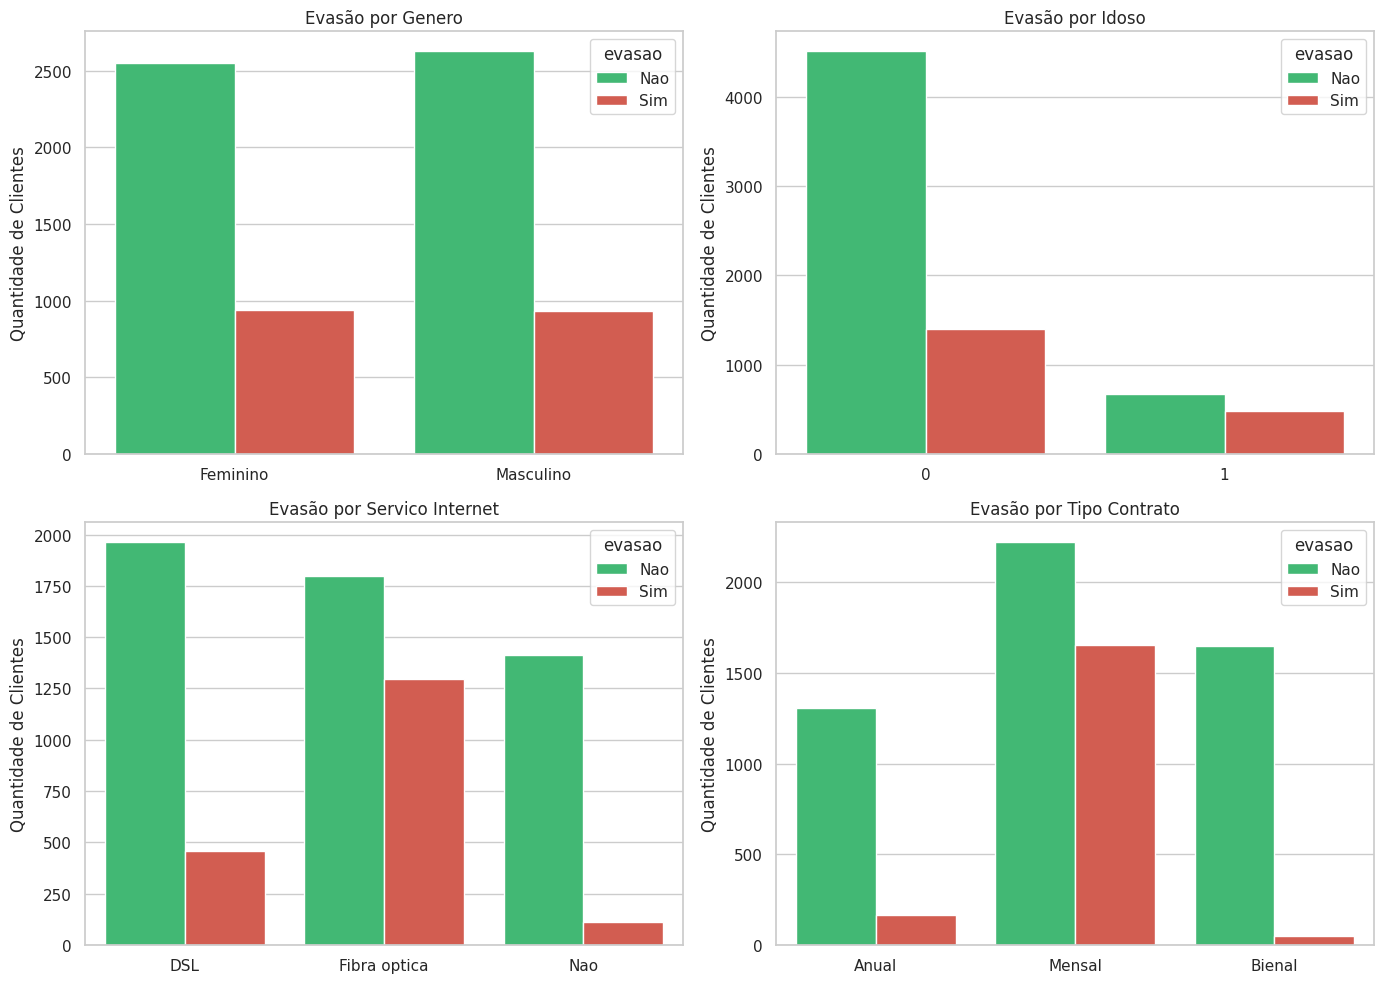

In [9]:
# 3. CONTAGEM DE EVASÃO POR VARIÁVEIS CATEGÓRICAS

# Escolhendo as colunas de texto (categorias) mais suspeitas para investigar
colunas_investigar = ['genero', 'idoso', 'servico_internet', 'tipo_contrato']

# Criando uma "tela" em branco para colocar 4 gráficos (2 linhas e 2 colunas)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

# Laço de repetição para desenhar os gráficos automaticamente
for i, coluna in enumerate(colunas_investigar):
    linha = i // 2
    coluna_pos = i % 2

    # Desenhando o gráfico
    # O "hue='evasao'" é a mágica aqui: ele divide cada barra em Sim/Não!
    sns.countplot(data=df_analise, x=coluna, hue='evasao',
                  palette=['#2ecc71', '#e74c3c'], ax=axes[linha, coluna_pos])

    # Ajustando os títulos
    axes[linha, coluna_pos].set_title(f'Evasão por {coluna.replace("_", " ").title()}', fontsize=12)
    axes[linha, coluna_pos].set_xlabel('')
    axes[linha, coluna_pos].set_ylabel('Quantidade de Clientes')

# Organizando o espaçamento para não ficar um por cima do outro
plt.tight_layout()
plt.show()

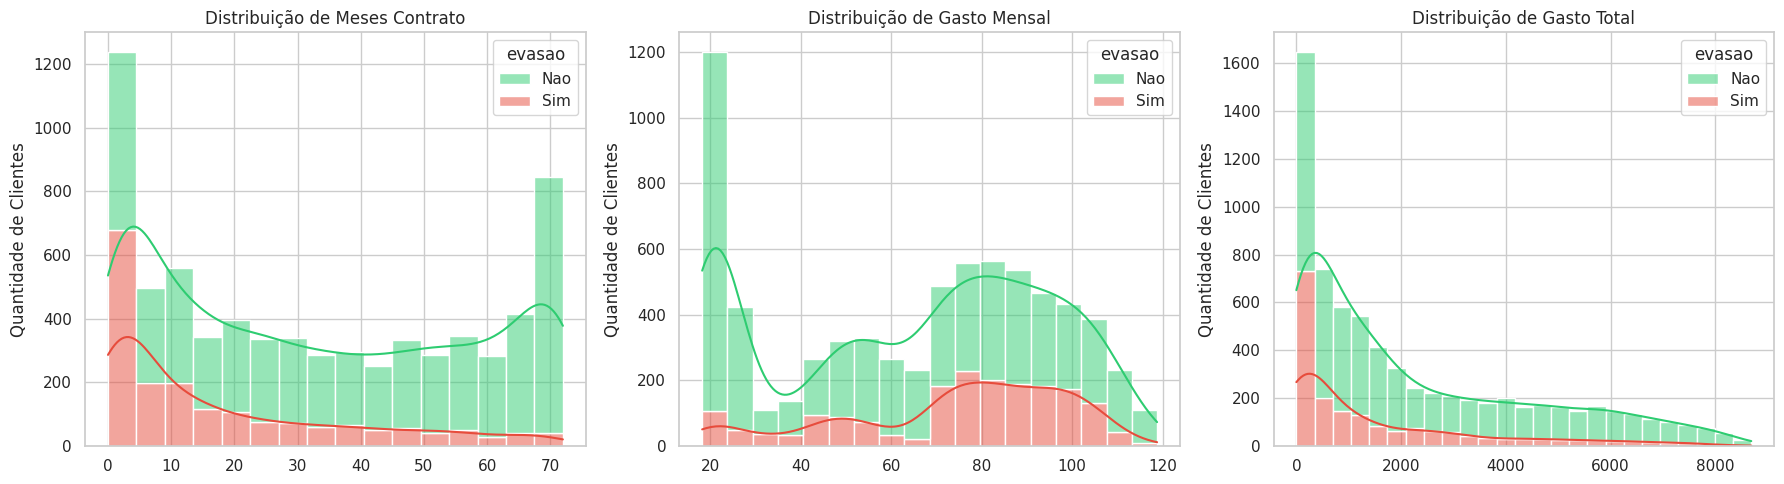

In [10]:
# 4. DISTRIBUIÇÃO DA EVASÃO POR VARIÁVEIS NUMÉRICAS

# Isolando as colunas numéricas
colunas_numericas = ['meses_contrato', 'gasto_mensal', 'gasto_total']

# Criando uma tela com 1 linha e 3 colunas (mais horizontal)
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

for i, coluna in enumerate(colunas_numericas):
    # Desenhando o Histograma com a linha de tendência (KDE)
    sns.histplot(data=df_analise, x=coluna, hue='evasao', multiple='stack',
                 palette=['#2ecc71', '#e74c3c'], kde=True, ax=axes[i])

    # Ajustando títulos
    axes[i].set_title(f'Distribuição de {coluna.replace("_", " ").title()}', fontsize=12)
    axes[i].set_ylabel('Quantidade de Clientes')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

#📄Relatorio Final

# Relatório Final: Análise de Evasão de Clientes (Churn) - Telecom X

## 1. Introdução e Objetivo
A Telecom X vem enfrentando um alto índice de evasão de clientes (Churn) e a equipe de Data Science foi acionada para investigar as causas desse fenômeno. O objetivo desta análise preliminar é realizar o processo de ETL (Extração, Transformação e Carga) de uma base de dados bruta, limpá-la e conduzir uma Análise Exploratória de Dados (EDA). Com os padrões identificados aqui, pavimentamos o caminho para a futura criação de modelos preditivos.

## 2. Processo de ETL (Extração, Transformação e Limpeza)
Os dados foram disponibilizados via API em um repositório no GitHub no formato JSON. O processo de tratamento seguiu as seguintes etapas:
* **Extração e Achatamento:** Como o arquivo JSON possuía estruturas aninhadas (dicionários dentro de dicionários), utilizamos a biblioteca `requests` em conjunto com a função `pd.json_normalize()` do Pandas para expandir os dados e criar um DataFrame tabular estruturado com 21 colunas.
* **Correção de Tipos de Dados:** Identificamos que a coluna de Gastos Totais (`gasto_total`) foi importada como texto (`object`) devido à presença de espaços em branco `" "` oriundos de clientes recém-cadastrados (com 0 meses de contrato). Convertidos esses dados para valores numéricos (`float`) e preenchemos os valores vazios com `0`.
* **Padronização:** Removemos prefixos das colunas originais (ex: `customer.`, `account.`) e traduzimos tanto os nomes das colunas quanto os valores categóricos internos para o português, visando facilitar a interpretação gráfica e a legibilidade do projeto.

## 3. Análise Exploratória de Dados (EDA)
A base final é composta por 7.267 registros. Descobrimos que a **taxa geral de evasão da empresa é de 26,54%**, o que significa que mais de 1/4 da base de clientes optou por cancelar os serviços.

Cruzando a variável alvo (`evasao`) com os dados categóricos e numéricos, obtivemos os seguintes *insights*:

* **Perfil Demográfico:** O gênero do cliente (Masculino ou Feminino) não apresenta nenhum impacto na taxa de cancelamento, com as proporções sendo praticamente idênticas.
* **Serviço de Internet:** Clientes que utilizam o serviço de **Fibra Óptica** possuem uma taxa de evasão alarmantemente superior aos clientes de internet DSL.
* **O Peso do Contrato Mensal:** O tipo de contrato é o maior preditor de Churn identificado na análise. Quase a totalidade das evasões ocorre entre clientes que possuem **contratos mensais**. Clientes com contratos anuais ou bienais são altamente fiéis.
* **Janela Crítica de Abandono (Tenure):** A análise da distribuição de meses de contrato mostrou um pico acentuado de cancelamentos nos **primeiros meses de assinatura**. Se o cliente passa dos primeiros meses, a probabilidade de evasão cai drasticamente.
* **Impacto Financeiro:** Notamos um volume expressivo de evasão em faturas com valor mensal entre **R$ 70,00 e R$ 110,00**. Planos mais baratos (na faixa de R$ 20,00) retêm muito mais os clientes.

## 4. Conclusões e Recomendações Estratégicas
A análise aponta que a Telecom X sofre de um problema crônico de retenção inicial, especialmente em serviços mais caros e sem fidelidade. Baseado nos dados, recomendamos as seguintes ações para a equipe de negócios:

1. **Ação contra Evasão Inicial:** Como o pico de cancelamentos ocorre nos primeiros meses, sugerimos a criação de um programa de *Onboarding* (boas-vindas) focado no sucesso do cliente, com suporte proativo e acompanhamento próximo nos primeiros 3 a 6 meses.
2. **Incentivo à Migração de Contrato:** Oferecer descontos agressivos ou benefícios extras para convencer os atuais clientes do plano Mensal a migrarem para os planos Anuais.
3. **Revisão da Fibra Óptica:** Investigar urgentemente o serviço de Fibra Óptica. A alta evasão cruzada com os cancelamentos em faturas mais altas (R$ 70 a R$ 110) sugere que os clientes não estão percebendo valor ou estão enfrentando problemas técnicos severos neste produto específico.

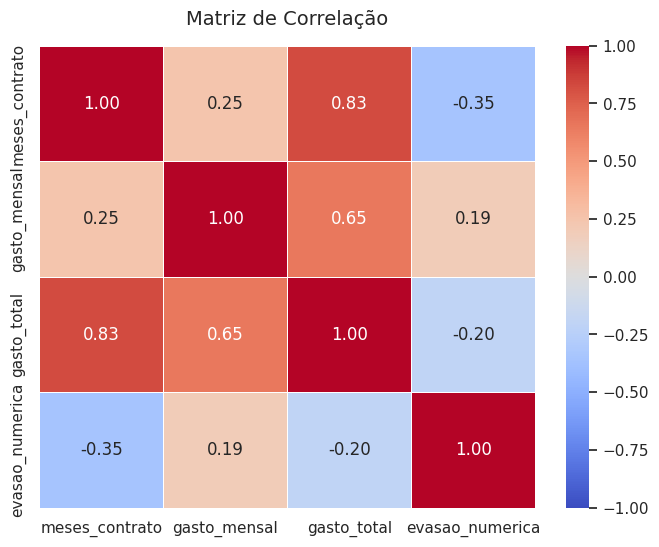

In [18]:
# ==========================================
# BÔNUS: MATRIZ DE CORRELAÇÃO (HEATMAP)
# ==========================================

# 1. Preparando os dados: transformando 'Sim'/'Nao' em 1 e 0
df_correlacao = df_analise.copy()
df_correlacao['evasao_numerica'] = df_correlacao['evasao'].map({'Sim': 1, 'Nao': 0})

# 2. Separando apenas as colunas numéricas para a matemática funcionar
colunas_numericas = ['meses_contrato', 'gasto_mensal', 'gasto_total', 'evasao_numerica']
matriz_corr = df_correlacao[colunas_numericas].corr()

# 3. Desenhando o gráfico (Heatmap)
plt.figure(figsize=(8, 6))

# annot=True mostra os números, cmap='coolwarm' define as cores (azul e vermelho)
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)

plt.title('Matriz de Correlação', fontsize=14, pad=15)
plt.show()